<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install -q --force-reinstall "scikit-learn==1.3.2" "umap-learn==0.5.5"


In [ ]:
!pip install -q \
  "langchain==0.3.27" \
  "langchain-community==0.3.31" \
  "langchain-core==0.3.79" \
  "langchain-text-splitters==0.3.11" \
  ragatouille \
  chromadb \
  sentence-transformers \
  plotly \
  gdown \
  transformers


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from typing import Optional, List, Tuple, Any

import torch
import gdown

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_core.documents import Document as LangchainDocument
from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain_community.vectorstores import Chroma

from langchain_community.vectorstores.utils import DistanceStrategy

from ragatouille import RAGPretrainedModel


In [ ]:
print("Torch CUDA:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Torch CUDA: True
CUDA device: Tesla P100-PCIE-16GB


## Загрузка данных (4 балла)

Погнали

In [ ]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)
raw = pd.read_csv("file.csv", encoding="utf-8-sig")

df = raw.drop(columns=["Unnamed: 0"])


Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=eee46dea-8b31-4129-bb06-94779ce65441
To: /kaggle/working/file.csv
100%|██████████| 672M/672M [00:02<00:00, 250MB/s] 


# Очистка датасета

In [ ]:
df.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удаляем лишние пробелы, приводим все к нижнему регистру и формируем две колонки:

place_hints (название+город)

text (название+город+описание из WikiData+сгенерированное описание)



In [ ]:
import re

def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = re.sub(r"\s+", " ", s.strip())
    s = s.lower()
    return s

def make_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["description"] = df["description"].map(normalize_text)
    df["en_txt"] = df["en_txt"].map(normalize_text)
    df["Name"] = df["Name"].map(normalize_text)
    df["City"] = df["City"].map(normalize_text)

    df["place_hints"] = (df["Name"] + " " + df["City"]).str.strip()
    df["text"] = (df["place_hints"] + " " + df["description"] + " " + df["en_txt"]).str.strip()

    return df

In [ ]:
df = make_text_columns(df.dropna(subset=['description', 'WikiData']).reset_index(drop=True))

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12078 entries, 0 to 12077
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         12078 non-null  object 
 1   WikiData     12078 non-null  object 
 2   City         12078 non-null  object 
 3   Lon          12078 non-null  float64
 4   Lat          12078 non-null  float64
 5   description  12078 non-null  object 
 6   image        12078 non-null  object 
 7   en_txt       12078 non-null  object 
 8   place_hints  12078 non-null  object 
 9   text         12078 non-null  object 
dtypes: float64(2), object(8)
memory usage: 943.7+ KB


Начинаем чистку мусора: удаляем дубликаты по en_txt

In [ ]:
print("До очистки:", len(df))

df_clean = df.drop_duplicates(subset=["en_txt"]).reset_index(drop=True)

print("После очистки:", len(df_clean))
print("Уникальных text:", df_clean["text"].nunique())

До очистки: 12078
После очистки: 8137
Уникальных text: 8137


Смотрим, сколько у нас уникальных идентификаторов и названий мест (надеемся, что количество будет одинаковым)

In [ ]:
print("Уникальных WikiData:", df_clean["WikiData"].nunique())
print("Уникальных place_hints:", df_clean["place_hints"].nunique())

Уникальных WikiData: 295
Уникальных place_hints: 317


Но нет, названий на 22 больше, чем идентификаторов. Посмотрим, почему.

In [ ]:
wd_to_ph = (
    df_clean.groupby("WikiData")["place_hints"]
         .nunique()
         .reset_index(name="n_place_hints")
)
print("Сколько Wikidata-ID имеют больше одного place_hints:")
print((wd_to_ph["n_place_hints"] > 1).sum())

wd_multi = wd_to_ph[wd_to_ph["n_place_hints"] > 1]
wd_multi

Сколько Wikidata-ID имеют больше одного place_hints:
22


,WikiData,n_place_hints
11,Q1078595,2
45,Q18406802,2
54,Q19692529,2
55,Q1984395,2
79,Q27921892,2
80,Q28032873,2
85,Q30709938,2
89,Q3329597,2
99,Q4087775,2
109,Q4113610,2


Ок, 22 Wikidata-ID имеют по 2 различных place_hints. Возьмем самое длинное и назначим каноничным.

In [ ]:
def pick_best_name(variants):
    uniq = list(set(variants))
    return max(uniq, key=len)

canonical_name = (
    df_clean.groupby("WikiData")["place_hints"]
         .apply(pick_best_name)
         .reset_index(name="canonical_place_name")
)

df_clean = df_clean.merge(canonical_name, on="WikiData", how="right")
df_clean["place_hints"] = df_clean["canonical_place_name"]

print("Уникальных WikiData:", df_clean["WikiData"].nunique())
print("Уникальных place_hints:", df_clean["place_hints"].nunique())
df_clean.drop(columns=["canonical_place_name"], inplace=True)
df_clean

Уникальных WikiData: 295
Уникальных place_hints: 295


,Name,WikiData,City,Lon,Lat,description,image,en_txt,place_hints,text
0,гарнизонная казарма,Q100701435,нижний новгород,44.004299,56.327614,"здание в нижегородском кремле, россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a green lawn and a blue roof,гарнизонная казарма нижний новгород,гарнизонная казарма нижний новгород здание в н...
1,гарнизонная казарма,Q100701435,нижний новгород,44.004299,56.327614,"здание в нижегородском кремле, россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large yellow building with a ...,гарнизонная казарма нижний новгород,гарнизонная казарма нижний новгород здание в н...
2,гарнизонная казарма,Q100701435,нижний новгород,44.004299,56.327614,"здание в нижегородском кремле, россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large yellow building with many win...,гарнизонная казарма нижний новгород,гарнизонная казарма нижний новгород здание в н...
3,гарнизонная казарма,Q100701435,нижний новгород,44.004299,56.327614,"здание в нижегородском кремле, россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a bunch of wind...,гарнизонная казарма нижний новгород,гарнизонная казарма нижний новгород здание в н...
4,гарнизонная казарма,Q100701435,нижний новгород,44.004299,56.327614,"здание в нижегородском кремле, россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large yellow building with a clock ...,гарнизонная казарма нижний новгород,гарнизонная казарма нижний новгород здание в н...
...,...,...,...,...,...,...,...,...,...,...
8132,дом сироткина,Q99929827,нижний новгород,44.012966,56.329269,"памятник архитектуры нижнего новгорода, корпус...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,an old photo of a large building with columns ...,дом сироткина нижний новгород,дом сироткина нижний новгород памятник архитек...
8133,дом сироткина,Q99929827,нижний новгород,44.012966,56.329269,"памятник архитектуры нижнего новгорода, корпус...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a statue of a man on a pedestal in fr...,дом сироткина нижний новгород,дом сироткина нижний новгород памятник архитек...
8134,дом сироткина,Q99929827,нижний новгород,44.012966,56.329269,"памятник архитектуры нижнего новгорода, корпус...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a car parked on the side of the road,дом сироткина нижний новгород,дом сироткина нижний новгород памятник архитек...
8135,дом сироткина,Q99929827,нижний новгород,44.012966,56.329269,"памятник архитектуры нижнего новгорода, корпус...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,people are looking at a painting of a large cr...,дом сироткина нижний новгород,дом сироткина нижний новгород памятник архитек...


Итак, у нас 295 различных локаций с кучей дубликатов.

In [ ]:
n_total = len(df_clean)
n_unique = df_clean["place_hints"].nunique()

print(f"Всего записей: {n_total}")
print(f"Уникальных place_hints: {n_unique}")
print(f"Дубликатов place_hints: {n_total - n_unique}")

Всего записей: 8137
Уникальных place_hints: 295
Дубликатов place_hints: 7842


In [ ]:
place_counts = df_clean["place_hints"].value_counts()

print("Максимум дублей для одного места:", place_counts.max())
print("Среднее количество дублей:", round(place_counts.mean(), 2))

Максимум дублей для одного места: 70
Среднее количество дублей: 27.58


Посмотрим на распределение количества записей на одну локацию

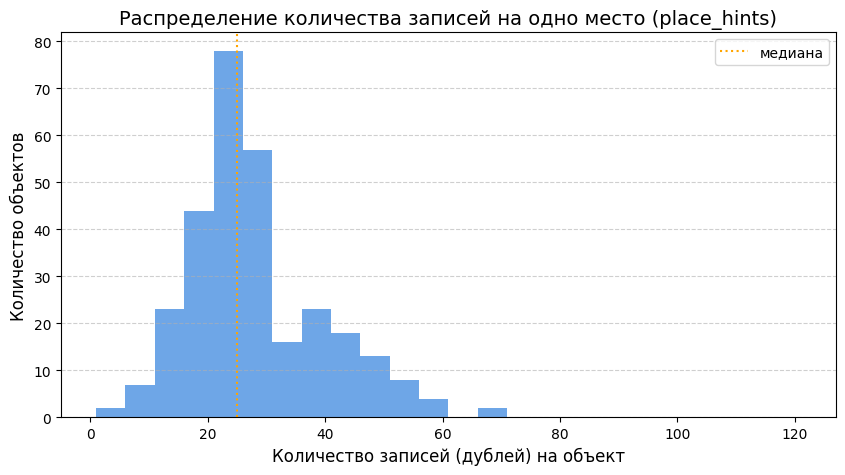

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df_clean["place_hints"].value_counts(), bins=range(1,125,5), color="#4a90e2", alpha=0.8)
plt.title("Распределение количества записей на одно место (place_hints)", fontsize=14)
plt.xlabel("Количество записей (дублей) на объект", fontsize=12)
plt.ylabel("Количество объектов", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.axvline(x=np.median(df_clean['place_hints'].value_counts()), color="orange", linestyle=":", label="медиана")
plt.legend()
plt.show()

И теперь пора убрать объекты с неадекватными описаниями. Для этого воспользуемся TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_clean['text'].astype(str)

vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w\w+\b",
        max_features=50000
    )
X = vectorizer.fit_transform(texts)
vocab = np.array(vectorizer.get_feature_names_out())

df_counts = np.asarray((X > 0).sum(axis=0)).ravel()

tfidf_sum = np.asarray(X.sum(axis=0)).ravel()
idf = vectorizer.idf_

stats = pd.DataFrame({
        "term": vocab,
        "df": df_counts,
        "idf": idf,
        "tfidf_sum": tfidf_sum,
        "avg_tfidf": tfidf_sum / df_counts
    })

rare = (stats[stats["term"].str.len() >= 1].sort_values("df", ascending=True).head(20))
freq = (stats[stats["term"].str.len() >= 1].sort_values("df", ascending=False).head(20))
candidates = pd.concat([rare["term"], freq["term"]]).unique().tolist()

candidates

['arabakexplus',
 'araface',
 'arafective',
 'arafexibular',
 'arafexor',
 'araffaat',
 'araffatured',
 'araffy',
 'technikym',
 'telephone',
 'telling',
 'tenness',
 'apparin',
 'appartiment',
 'applauding',
 'applied',
 'arafson',
 'architecture',
 'arm',
 'armor',
 'with',
 'of',
 'and',
 'building',
 'arafed',
 'in',
 'ярославль',
 'on',
 'there',
 'екатеринбург',
 'нижний',
 'новгород',
 'is',
 'the',
 'екатеринбурге',
 'view',
 'large',
 'front',
 'church',
 'white']

А это результат долгих чтений текстов из описаний:

In [ ]:
SUSPECT_PATTERNS = [
    r"\bportrait(s)?\b",
    r"\bmodels?\b",
    r"\bpeople\b",
    r"\bpark(?:ing|ed)\b",
    r"\ban?\s+(?:view|picture|image|photo)\s+of\b",
    r"\bpainting\b",
    r"\ba\s+view\s+of\b",
    r"\bpicture of\b",
    r"\ban?\s+image of\b",
    r"\bcars?\b",
    r"\bmaps?\b",
    r"\badvert(?:ising|isement)?\b",
    r"\bмем(?!ориал)\b",
    r"\bmemes?\b",
    r"\bбаннер(?:ы)?\b",
    r"\bposter\b",
    r"\bbillboards?\b",
    r"\binstagram\b", r"\bvk\.com\b", r"\btiktok\b", r"\bfacebook\b", r"\btwitter\b",
    r"\bselfie\b", r"\bселфи\b",
    r"\bstock\s+photo\b", r"\bwatermark\b", r"\bshutterstock\b", r"\bgetty\b",
]


Отфильтруем строки с подозрительными паттернами, коих оказалось почти 20%

In [ ]:
import re
compiled = [re.compile(p, flags=re.IGNORECASE) for p in SUSPECT_PATTERNS]

def flag_regex(t):
    t = (t or "").lower()
    return any(p.search(t) for p in compiled)

df_clean["is_suspect_regex"] = df_clean["text"].apply(flag_regex)
print("Доля 'подозрительных' по regex:", df_clean["is_suspect_regex"].mean().round(3))

df_clean = df_clean[~df_clean["is_suspect_regex"]].copy()

Доля 'подозрительных' по regex: 0.191


А теперь проверим description и en_txt на соответствие по смысловой близости (смотрим на косинусное сходство)

In [ ]:
TARGET_N = 250
SIM_THRESHOLD = 0.25
MIN_LEN_EN = 20
MAX_FINAL_CHARS = 2500
TOPK_PER_PLACE = 3
df_in = df_clean.copy()

In [ ]:
def norm(s):
    import re
    if not isinstance(s, str): return ""
    s = s.replace("\u200b"," ").replace("\xa0"," ")
    s = re.sub(r"\s+"," ", s.strip())
    return s

for col in ["description","en_txt","Name","City","place_hints"]:
    if col in df_in.columns:
        df_in[col] = df_in[col].fillna("").astype(str).map(norm)

In [ ]:
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

desc = df_in["description"].tolist()
entx = df_in["en_txt"].tolist()

emb_d = model.encode(desc, batch_size=128, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
emb_e = model.encode(entx, batch_size=128, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)

df_in["similarity"] = (emb_d * emb_e).sum(axis=1)
mask_good = (
    (df_in["en_txt"].str.len() >= MIN_LEN_EN) &
    (df_in["similarity"] >= SIM_THRESHOLD)
)
df_good = df_in[mask_good].copy()

Теперь еще раз обратимся к TF-IDF: для каждого места найдем самое "среднестатистическое" описание, выберем несколько наиболее синонимичных к нему (но не дублей) и склеиваем их в один текст

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def topk_typical_texts(texts, k=5):
    if len(texts) <= k:
        return list(range(len(texts)))
    vec = TfidfVectorizer(max_features=30000, token_pattern=r"(?u)\b[\w\-]{2,}\b", lowercase=True)
    X = vec.fit_transform(texts)
    centroid = np.asarray(X.mean(axis=0)).ravel().reshape(1, -1)
    sims = cosine_similarity(X, centroid).ravel()
    order = np.argsort(-sims)
    picked = []
    used = set()
    for i in order:
        if texts[i] in used:
            continue
        picked.append(i)
        used.add(texts[i])
        if len(picked) >= k:
            break
    return picked

def build_text_final(grp, k=3, max_chars=2500):

    candidates = grp["en_txt"].tolist()
    idxs = topk_typical_texts(candidates, k=min(k, max(1, len(candidates))))
    parts = [candidates[i] for i in idxs if isinstance(candidates[i], str) and candidates[i].strip()]
    text_final = " ".join(parts)
    text_final = " ".join(text_final.split())
    if not text_final:
        full_grp = df_in.loc[grp.index]
        fallback = full_grp["en_txt"].astype(str)
        if fallback.str.len().max() < MIN_LEN_EN:
            fallback = full_grp["description"].astype(str)
        text_final = fallback.iloc[fallback.str.len().argmax()]
    return text_final[:max_chars].strip()

Произведем агрегацию по place_hints: теперь на одну локацию приходится всего одно описание с наименьшим количеством мусора

In [ ]:
agg_rows = []
for place, grp_all in df_in.groupby("place_hints", dropna=False):
    inter_idx = grp_all.index.intersection(df_good.index)
    grp_good = df_good.loc[inter_idx]
    use_grp = grp_good if len(grp_good) > 0 else grp_all
    text_final = build_text_final(use_grp, k=TOPK_PER_PLACE, max_chars=MAX_FINAL_CHARS)

    row0 = grp_all.iloc[0]
    agg_rows.append({
        "place_hints": place,
        "WikiData": row0.get("WikiData", ""),
        "Name": row0.get("Name",""),
        "City": row0.get("City",""),
        "description": row0.get("description",""),
        "image": row0.get("image",""),
        "n_records_total": len(grp_all),
        "n_records_used": len(use_grp),
        "sim_mean_used": float(use_grp["similarity"].mean()) if "similarity" in use_grp else np.nan,
        "sim_min_used": float(use_grp["similarity"].min()) if "similarity" in use_grp else np.nan,
        "text_final": text_final
    })


df_places = pd.DataFrame(agg_rows)

In [ ]:
df_places

,place_hints,WikiData,Name,City,description,image,n_records_total,n_records_used,sim_mean_used,sim_min_used,text_final
0,cerkiew narodzenia pańskiego w jarosławiu ярос...,Q28058985,cerkiew narodzenia pańskiego w jarosławiu,ярославль,православный храм в ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,20,20,0.514121,0.330149,there is a wooden building with a steeple on t...
1,cerkiew włodzimierskiej ikony matki bożej w ja...,Q30913943,cerkiew włodzimierskiej ikony matki bożej w ja...,ярославль,архитектурный ансамбль в ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,37,36,0.526959,0.329956,there is a blue church with a steeple and a cr...
2,cerkiew św. dymitra sołuńskiego w jarosławiu я...,Q28056804,cerkiew św. dymitra sołuńskiego w jarosławiu,ярославль,церковь великомученика димитрия солунского (см...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,39,38,0.448321,0.260748,there is a wooden building with a steeple on t...
3,église arménienne de vladimir владимир,Q18331756,église arménienne de vladimir,владимир,армянская церковь в г. владимир россии,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,13,2,0.403017,0.395776,arafed view of a city with a clock tower and a...
4,авиамеханический колледж владимир,Q18786015,авиамеханический колледж,владимир,владимирский авиамеханический колледж,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,13,3,0.298459,0.263967,arafexibular building with a sign that says ar...
...,...,...,...,...,...,...,...,...,...,...,...
290,№19 музей истории екатеринбурга екатеринбург,Q4306294,№19 музей истории екатеринбурга,екатеринбург,музей в екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,29,29,0.418658,0.315481,there is a large building with a sign on the f...
291,№27 дом г.н. скрябина екатеринбург,Q55232375,№27 дом г.н. скрябина,екатеринбург,дом е.д. скрябиной,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,18,16,0.374867,0.257080,there is a building with a sign on the front o...
292,№28 здание городской электростанции «луч» екат...,Q55154121,№28 здание городской электростанции «луч»,екатеринбург,здание и достопримечательность в екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,12,12,0.542863,0.364223,there is a red brick building with a chimney o...
293,№32 дом обороны екатеринбург,Q55209768,№32 дом обороны,екатеринбург,здание в екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,21,21,0.567754,0.351935,arafed building with a plane on top of it in a...


Ну и наконец составим итоговый датасет, причем постараемся выбрать локации так, чтобы их число для каждого города было примерно одинаковым

In [ ]:
def balanced_sample_by_city(df, target_n=250, random_state=42):
    import random
    rng = random.Random(random_state)
    groups = list(df.groupby("City", dropna=False))

    if len(groups) == 0:
        return df.head(target_n).copy()
    base_quota = max(1, target_n // len(groups))
    picks_idx = []

    for city, g in groups:
        chosen = g.sample(n=min(base_quota, len(g)), random_state=rng.randint(0,10**9)).index.tolist()
        picks_idx.extend(chosen)

    if len(picks_idx) < target_n:
        remain_pool = df.drop(index=picks_idx).sort_values(["n_records_used","n_records_total"], ascending=False)
        extra = remain_pool.head(target_n - len(picks_idx)).index.tolist()
        picks_idx.extend(extra)
    return df.loc[picks_idx[:target_n]].reset_index(drop=True)

df_places = df_places[df_places["text_final"].str.len() >= MIN_LEN_EN].reset_index(drop=True)
df_rag = balanced_sample_by_city(df_places, target_n=TARGET_N)


Маленький костыль из будущего:

In [ ]:
print(f"Готово. Документов для RAG: {len(df_rag)} из {len(df_places)} мест (всего {len(df_in)} строк).")


Готово. Документов для RAG: 250 из 295 мест (всего 6586 строк).


In [ ]:
import re

def clean_caption(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r"\barafed\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_rag["text_final_clean"] = df_rag["text_final"].apply(clean_caption)
df_rag.drop(columns=["text_final", "n_records_total", "n_records_used", "sim_mean_used", "sim_min_used"], inplace=True)
df_rag

,place_hints,WikiData,Name,City,description,image,text_final_clean
0,владимирский государственный гуманитарный унив...,Q4113277,владимирский государственный гуманитарный унив...,владимир,владимирский государственный гуманитарный унив...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a sign that says the ...
1,богородице-рождественский мужской монастырь вл...,Q4089667,богородице-рождественский мужской монастырь,владимир,богородице-рождественский монастырь (владимир),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,view of a church with a steeple and a golden d...
2,владимирский централ владимир,Q240549,владимирский централ,владимир,тюрьма в городе владимир,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue building with a gate and a red...
3,église arménienne de vladimir владимир,Q18331756,église arménienne de vladimir,владимир,армянская церковь в г. владимир россии,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,view of a city with a clock tower and a church...
4,здание городской думы владимир,Q21639718,здание городской думы,владимир,здание городской думы,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,nighttime view of a large building with a cloc...
...,...,...,...,...,...,...,...
245,собор архангела михаила нижний новгород,Q1365942,собор архангела михаила,нижний новгород,православный храм,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,view of a church with a green roof and a white...
246,№32 дом обороны екатеринбург,Q55209768,№32 дом обороны,екатеринбург,здание в екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,building with a plane on top of it in a city v...
247,часовня казанской богоматери ярославль,Q3657520,часовня казанской богоматери,ярославль,часовня казанской богоматери (ярославль),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a white church with a cross on the to...
248,нижегородский кремль нижний новгород,Q1550905,нижегородский кремль,нижний новгород,крепость в центре нижнего новгорода,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,view of a city with a castle on a hill view of...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [ ]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

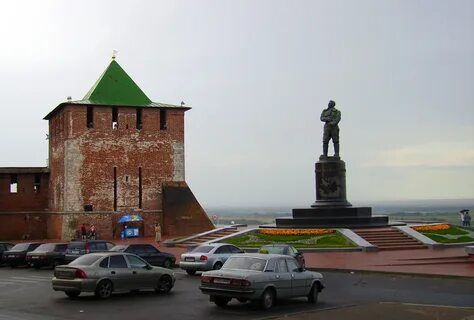

In [ ]:
get_image(df.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
import matplotlib.pyplot as plt
import math
import textwrap

def show_images(df_subset, n=12, ncols=4, random=False, title_max=80):

    if random and len(df_subset) > n:
        sub = df_subset.sample(n, random_state=42).reset_index(drop=True)
    else:
        sub = df_subset.head(n).reset_index(drop=True)

    n = len(sub)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(4*ncols, 4*nrows))

    for i in range(n):
        b64 = sub.iloc[i]["image"]
        name = str(sub.iloc[i].get("Name", ""))
        txt  = str(sub.iloc[i].get("description")
                   or "")
        title = f"{name}\n{textwrap.shorten(txt, width=title_max, placeholder='…')}"
        try:
            img = get_image(b64)
            plt.subplot(nrows, ncols, i+1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(title, fontsize=9)
        except Exception as e:
            plt.subplot(nrows, ncols, i+1)
            plt.text(0.5, 0.5, f"Ошибка изображения:\n{e}", ha="center", va="center")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


Посмотрим на изображения отфильтрованных локаций

In [ ]:
show_images(df_rag, n=25, ncols=5)

Выглядит очень адекватно

# RAG


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Преобразуем строки датафрейма в LangChain-документы

In [ ]:
def row_to_document(row) -> LangchainDocument:
    desc = str(row["description"])
    img_desc = str(row["text_final_clean"])

    page_content = "\n".join([
        f"Название: {row['Name']}",
        f"Город: {row['City']}",
        "",
        "Описание (WikiData):",
        desc,
        "",
        "Описание по фото:",
        img_desc,
    ])

    metadata = {
        "place_hints": row["place_hints"],
        "wikidata_id": row["WikiData"],
        "city": row["City"],
        "image_base64": row["image"],
    }

    return LangchainDocument(page_content=page_content, metadata=metadata)

RAW_KNOWLEDGE_BASE = [row_to_document(r) for _, r in df_rag.iterrows()]
len(RAW_KNOWLEDGE_BASE)


250

В качестве модели эмбеддингов используем multilingual-e5-base. Так как у нас в датасете смесь русского, английского и польского, поддержка нескольких языков лишней не будет

In [ ]:
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-base"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True}
)


Проверим, не слишком ли наши тексты длинны для embedding-модели.

In [ ]:
tok = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-base")

df_rag["len_tokens"] = df_rag["text_final_clean"].apply(lambda x: len(tok.encode(str(x))))
df_rag["len_tokens"].describe()

count    250.000000
mean      40.704000
std        5.840619
min       11.000000
25%       38.000000
50%       41.000000
75%       45.000000
max       53.000000
Name: len_tokens, dtype: float64

In [ ]:
max_len_text = df_rag["len_tokens"].max()
max_len_model = SentenceTransformer("intfloat/multilingual-e5-base").max_seq_length

print("Максимальная длина текстов:", max_len_text)
print("Максимальная длина модели:", max_len_model)

Максимальная длина текстов: 53
Максимальная длина модели: 512


Норм, можно спокойно использовать тексты целиком

Далее инициализируем Chroma, для доранжирования документов будем использовать colbertv2.0 и Mistral-7B-Instruct в качестве Reader

In [ ]:
KNOWLEDGE_VECTOR_DATABASE = Chroma.from_documents(
    RAW_KNOWLEDGE_BASE,
    embedding_model,
    collection_name="tourism_rag",
    persist_directory="chroma_tourism_db_v2",
)

In [ ]:
RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
READER_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"

reader_tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

reader_model = AutoModelForCausalLM.from_pretrained(
    READER_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)

READER_LLM = pipeline(
    model=reader_model,
    tokenizer=reader_tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.3,
    top_p=0.9,
    repetition_penalty=1.1,
    max_new_tokens=400,
    return_full_text=False,
)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

Достаём эмбеддинги из Chroma

In [ ]:
embeddings = KNOWLEDGE_VECTOR_DATABASE._collection.get(include=["embeddings"])["embeddings"]
embeddings = np.array(embeddings)
embeddings.shape

(250, 768)

PCA-визуализация

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(embeddings)

df_pca = pd.DataFrame({
    "pc1": emb_pca[:, 0],
    "pc2": emb_pca[:, 1],
    "city": df_rag["City"].values,
    "place": df_rag["Name"].values
})

fig = px.scatter(
    df_pca, x="pc1", y="pc2",
    color="city",
    hover_data=["place"],
    title="PCA проекция эмбеддингов"
)
fig.show()


Линейная проекция улавливает разделение по городам, но делает это слабее, чем хотелось бы. Нижний Новгород выделяется изолированней остальных, Владимир смешался с оставшимися двумя городами. При детальном просмотре можно заметить, что ярославские монастыри и храмы сгруппированы в один кластер. Аналогично для башен Нижнего Новгорода

UMAP-визуализация

In [ ]:
import umap
import pandas as pd
import plotly.express as px

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine"
)

emb_umap = umap_model.fit_transform(embeddings)

df_umap = pd.DataFrame({
    "u1": emb_umap[:, 0],
    "u2": emb_umap[:, 1],
    "city": df_rag["City"].values,
    "place": df_rag["Name"].values
})

fig = px.scatter(
    df_umap, x="u1", y="u2",
    color="city",
    hover_data=["place"],
    title="UMAP проекция эмбеддингов"
)
fig.show()


UMAP создаёт четкие, компактные и почти не пересекающиеся группы по городам. Башни, храмы, дома, учебные заведения и памятники также группируются вместе. Отличнейше!

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

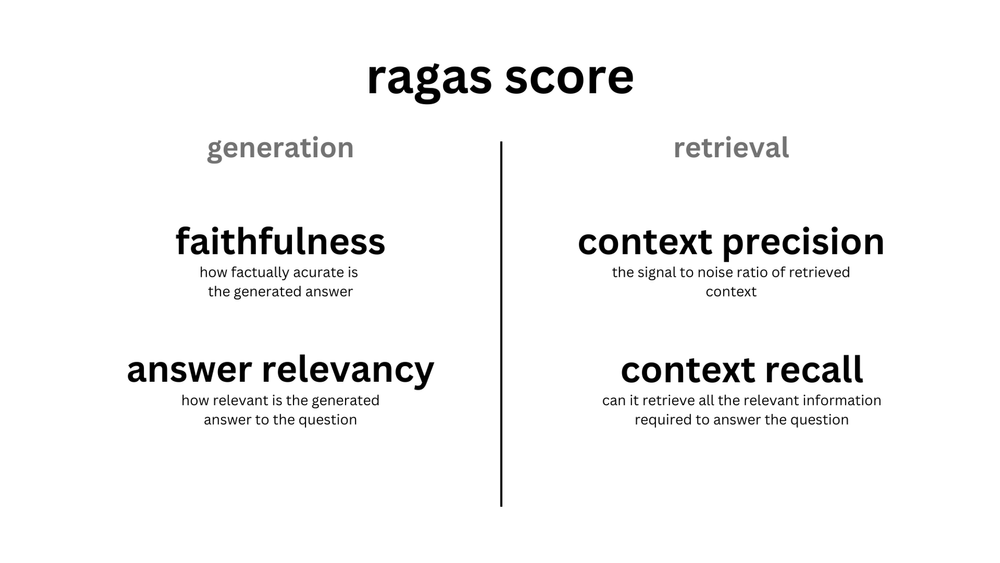

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

Итак, реализуем это.

In [ ]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Ты — аккуратный и дружелюбный туристический гид.
Отвечай ТОЛЬКО на основе предоставленного контекста.
Запрещено придумывать факты, которых нет в тексте.
Если информации недостаточно, честно скажи об этом.
Отвечай по-русски, ясно и по делу, как человеку, который планирует поездку.
Когда уместно, упоминай название достопримечательности и город.""",
    },
    {
        "role": "user",
        "content": """Контекст:
{context}
---
Вопрос: {question}""",
    },
]

RAG_PROMPT_TEMPLATE = reader_tokenizer.apply_chat_template(
    prompt_in_chat_format,
    tokenize=False,
    add_generation_prompt=True,
)

Создадим функцию, формирующую ответ на вопрос с помощью RAG:

1.   Достаем k похожих документов из векторной БД
2.   Формируем текстовый контекст
3.   Генерируем ответ LLM по промпту
4.   Возвращаем ответ и использованные текстовые контексты


In [ ]:
def answer_with_tourism_rag(
    question: str,
    llm,
    knowledge_index,
    num_retrieved_docs: int = 5,
    num_docs_final: int = 3,
):

    docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)
    texts = [doc.page_content for doc in docs][:num_docs_final]

    context = "\nExtracted documents:\n" + "".join(
        f"Document {i}:::\n{text}\n\n" for i, text in enumerate(texts)
    )

    final_prompt = RAG_PROMPT_TEMPLATE.format(
        question=question,
        context=context,
    )
    generations = llm(
        final_prompt,
        max_new_tokens=60,
        do_sample=False,
        temperature=0.0,
    )

    if isinstance(generations, list):
        answer = generations[0]["generated_text"]
    else:
        answer = generations["generated_text"]

    return answer, texts


HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

Выбираем 100 записей и для каждой строим:

1. question - автоматически сформулированный вопрос по названию места

2. answer - ответ, который выдаёт наш RAG

3. contexts - документы, извлечённые из векторной базы (E5 + Chroma)

4. ground_truths - описание из WikiData

5. followup_questions - три вопроса, сгенерированных на основе ответа модели

In [ ]:
def generate_followup_questions(answer: str, llm, n: int = 3):
    prompt = f"""
    Ты ассистент, который придумывает уточняющие вопросы по тексту.

    Даже если текст короткий или содержит мало информации — всё равно СФОРМУЛИРУЙ РОВНО {n} вопросов.
    Используй любую деталь, даже если текст обрывается.

    Формат ответа строго JSON:
    {{
      "questions": [
        "...",
        "...",
        "..."
      ]
    }}

    Ответ:
    \"\"\"{answer}\"\"\"
        """.strip()

    out = llm(
        prompt,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.6,
        top_p=0.9,
    )

    text = out[0]["generated_text"] if isinstance(out, list) else out["generated_text"]

    import json
    try:
        json_str = re.search(r"\{.*\}", text, re.DOTALL).group(0)
        obj = json.loads(json_str)
        qs = obj.get("questions", [])
    except:
        qs = []

    if len(qs) == 0:
        qs = [
            f"О чём говорится в тексте?",
            f"Где находится описанный объект?",
            f"Какая особенность упоминается в ответе?"
        ]

    return qs[:n]


In [ ]:
from tqdm.auto import tqdm
import json
import os

def data_preprocess(df: pd.DataFrame,
                    n_samples: int = 100,
                    save_path: str = "df_eval_partial.parquet"):

    df_eval = df.sample(n_samples, random_state=42).copy()

    df_eval["question"] = df_eval.apply(
        lambda r: f"Что такое {r['Name']} в городе {r['City']}?",
        axis=1,
    )

    df_out = pd.DataFrame()
    if os.path.exists(save_path):
        df_out = pd.read_parquet(save_path)
        print(f"Найден готовый df_eval c {len(df_out)} строками. Продолжаем…")

    start_from = len(df_out)
    print(f"Начали с индекса: {start_from}/{n_samples}")
    for idx, row in tqdm(df_eval.iloc[start_from:].iterrows(),
                         total=n_samples - start_from):

        q = row["question"]

        ans, ctx_docs = answer_with_tourism_rag(
            question=q,
            llm=READER_LLM,
            knowledge_index=KNOWLEDGE_VECTOR_DATABASE,
            num_retrieved_docs=5,
            num_docs_final=3,
        )

        fqs = generate_followup_questions(ans, llm=READER_LLM, n=3)
        gt = [str(row["description"])]

        new_row = row.to_dict()
        new_row.update({
            "answer": ans,
            "contexts": ctx_docs,
            "followup_questions": fqs,
            "ground_truths": gt,
        })

        df_out = pd.concat([df_out, pd.DataFrame([new_row])],
                           ignore_index=True)
        df_out.to_parquet(save_path, index=False)

    print(f"Сохранено: {len(df_out)} строк.")
    return df_out


In [ ]:
df_eval = data_preprocess(df_rag, 100, save_path="df_eval_100.parquet")
df_eval.head()

Начали с индекса: 0/100


  0%|          | 0/100 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_i

Сохранено: 100 строк.


,place_hints,WikiData,Name,City,description,image,text_final_clean,len_tokens,question,answer,contexts,followup_questions,ground_truths
0,нижегородский острог нижний новгород,Q4318666,нижегородский острог,нижний новгород,нижегородский острог,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,view of a white building with a tower and a cl...,43,Что такое нижегородский острог в городе нижний...,Нижегородский острог - это историческое соору...,[Название: нижегородский острог\nГород: нижний...,"[Какое историческое сооружение речь идет?, Где...",[нижегородский острог]
1,костел святого розария пресвятой девы марии ри...,Q3580427,костел святого розария пресвятой девы марии ри...,владимир,католический храм в городе владимир,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,church with a clock tower and a fence in front...,47,Что такое костел святого розария пресвятой дев...,Костел Святого Розария Пресвятой Девы Марии -...,[Название: костел святого розария пресвятой де...,[Какой религиозной конфессии принадлежит Косте...,[католический храм в городе владимир]
2,храм живоначальной троицы нижний новгород,Q16715808,храм живоначальной троицы,нижний новгород,соборный храм в нижегородском районе нижнего н...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a yellow building with a green steepl...,43,Что такое храм живоначальной троицы в городе н...,Храм Живоначальной Троицы - это соборный храм...,[Название: храм живоначальной троицы\nГород: н...,[Какой район находится храм Живоначальной Трои...,[соборный храм в нижегородском районе нижнего ...
3,гимназия № 9 екатеринбург,Q15298893,гимназия № 9,екатеринбург,здание в екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large white building with a fence i...,37,Что такое гимназия № 9 в городе екатеринбург?,"Гимназия № 9 - это здание, расположенное в Ек...",[Название: гимназия № 9\nГород: екатеринбург\n...,[Какое учебное заведение расположено в Екатери...,[здание в екатеринбурге]
4,часовая башня нижний новгород,Q51885220,часовая башня,нижний новгород,круглая башня нижегородского кремля,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a brick building with a clock tower o...,47,Что такое часовая башня в городе нижний новгород?,Часовая башня в Нижнем Новгороде - это кругла...,[Название: часовая башня\nГород: нижний новгор...,[Какая башня находится в Нижегородском Кремле?...,[круглая башня нижегородского кремля]


In [ ]:
def answer_relevancy(df, model=None, model_name="intfloat/multilingual-e5-base"):
    if model is None:
        model = SentenceTransformer(model_name)
    answers = df["answer"].astype(str).tolist()
    followups = df["followup_questions"].tolist()

    ans_emb = model.encode(answers, normalize_embeddings=True)

    relevancies = []

    for i, fq_list in enumerate(followups):

        if not isinstance(fq_list, list) or len(fq_list) == 0:
            relevancies.append(0.0)
            continue
        fq_emb = model.encode(fq_list, normalize_embeddings=True)
        sims = fq_emb @ ans_emb[i]

        relevancies.append(float(np.mean(sims)))

    return float(np.mean(relevancies)), relevancies


In [ ]:
e5_model = SentenceTransformer("intfloat/multilingual-e5-base")

mean_rel, rel_list = answer_relevancy(df_eval, model=e5_model)
print("Средняя answer_relevancy:", mean_rel)

Средняя answer_relevancy: 0.8497123938798904


Метрика показывает, что ответы модели в среднем хорошо соответствуют вопросу, нет значимого отклонения от курса, модель удерживает фокус на том, о чём спрашивали.

# Протестируйте ваш RAG (3 балла)

Проапгрейдим функцию answer_with_tourism_rag:


1. Извлекаем top-k документов из Chroma
2. Удаляем дубликаты,
3. Доранжируем документы через ColBERT,
4. Собираем контекст и делаем запрос LLM
5. Возвращает ответ и использованные текстовые документы

In [ ]:
from transformers import Pipeline
from typing import List, Tuple, Optional, Any
from ragatouille import RAGPretrainedModel

def production_answer_with_tourism_rag(
    question: str,
    llm: Pipeline,
    knowledge_index: Any,
    reranker: Optional[RAGPretrainedModel],
    num_retrieved_docs: int = 20,
    num_docs_final: int = 5,
) -> Tuple[str, List[str]]:

    print("=> Retrieving documents...")
    docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)
    texts = [doc.page_content for doc in docs]

    before = len(texts)
    texts = list(dict.fromkeys(texts))
    after = len(texts)
    if after < before:
        print(f"=> Removed {before - after} duplicate documents before reranking")

    reranked = reranker.rerank(question, texts, k=num_docs_final)
    texts = [d["content"] for d in reranked]

    texts = texts[:num_docs_final]
    context = "\nExtracted documents:\n" + "".join(
        f"Document {i}:::\n{text}\n\n" for i, text in enumerate(texts)
    )

    final_prompt = RAG_PROMPT_TEMPLATE.format(
        question=question,
        context=context,
    )

    print("=> Generating answer...")
    generations = llm(final_prompt)
    if isinstance(generations, list):
        answer = generations[0]["generated_text"]
    else:
        answer = generations["generated_text"]

    return answer, texts


In [ ]:
question = "Что посмотреть в Ярославле, если люблю старинные храмы и набережную?"

answer, docs_used = production_answer_with_tourism_rag(
    question=question,
    llm=READER_LLM,
    knowledge_index=KNOWLEDGE_VECTOR_DATABASE,
    reranker=RERANKER,
    num_retrieved_docs=20,
    num_docs_final=5,
)

print("=== ANSWER ===")
print(answer)

print("\n=== SOURCE DOCS (shortened) ===")
for i, t in enumerate(docs_used):
    print(f"\n--- Document {i} ---")
    print(t[:300], "...")


/usr/local/lib/python3.11/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



=> Retrieving documents...


100%|██████████| 1/1 [00:00<00:00,  8.05it/s]
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=> Generating answer...
=== ANSWER ===
 В Ярославле вы можете посетить несколько старинных храмов, которые будут вам понравиться. Среди них:

1. Храм Ярославской иконы Божией Матери - это небольшой храм с крышей в зелёном цвете и шпилем. Он расположен в центре города.

2. Приход Вознесения Святого Креста - это голубая церковь с часовой башней и шпилем. Она также находится в центре города.

3. Старообрядческий храм Иоанна Златоуста в Коровниках - это здание с зелёной крышей и куполами. Этот храм расположен в южной части города.

4. Церковь Михаила Архангела - это здание с двумя башнями и крестом на вершине. Она находится в центральной части города.

5. Толгский Ярославский монастырь в честь Введения во храм Пресвятой Богородицы - это женский монастырь с белой кирпичной стенной живописью и зелёной крышей. Он расположен в северной части города.

Кроме того, Ярославль имеет красивую набережную, которая протянулась вдоль реки Волги. Вы можете отправиться на экскурсию по набережной и увидеть

Ну огонь же!

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

Реализуем Context Precision и Context Recall

In [ ]:
def is_relevant_context(row, ctx: str) -> bool:

    name = str(row["Name"]).lower()
    city = str(row["City"]).lower()
    text = str(ctx).lower()

    name_tokens = set(name.split())
    city_tokens = set(city.split())
    text_tokens = set(text.split())

    has_name_word = len(name_tokens & text_tokens) > 0
    has_city_word = len(city_tokens & text_tokens) > 0

    return has_name_word and has_city_word


def context_recall(df_eval):
    recalls = []

    for _, row in df_eval.iterrows():
        ctx_list = row["contexts"]

        if not isinstance(ctx_list, list) or len(ctx_list) == 0:
            recalls.append(0.0)
            continue

        flags = [is_relevant_context(row, ctx) for ctx in ctx_list]
        recalls.append(1.0 if any(flags) else 0.0)

    return float(np.mean(recalls)), recalls


def context_precision(df_eval):
    precisions = []

    for _, row in df_eval.iterrows():
        ctx_list = row["contexts"]

        if not isinstance(ctx_list, list) or len(ctx_list) == 0:
            precisions.append(0.0)
            continue

        flags = [is_relevant_context(row, ctx) for ctx in ctx_list]
        precision = sum(flags) / len(flags)
        precisions.append(precision)

    return float(np.mean(precisions)), precisions


In [ ]:
mean_cr, cr_list = context_recall(df_eval)
mean_cp, cp_list = context_precision(df_eval)

print("Средняя context_recall:", mean_cr)
print("Средняя context_precision:", mean_cp)

Средняя context_recall: 1.0
Средняя context_precision: 0.66


RAG корректно извлекает релевантные данные и даёт модели достаточно информации для генерации правильного ответа, при этом ответы в среднем точно соответствуют вопросу. Система всегда извлекает всю нужную информацию, но также прихватывает и немного лишнего